# 05 — RoBERTa Test Inference and Submission

This Kaggle-ready notebook loads the completed **RoBERTa-base + LoRA** model from notebook 03, predicts every row of the untouched processed test set, performs label-free diagnostics, and creates the official `q2_submission.csv`.

The test set has no `overall` labels, so test Accuracy/F1 cannot be calculated. Model selection remains based on validation micro F1. Do not use prediction confidence or class distribution to claim test accuracy.

## Kaggle inputs

Attach these two inputs before running:

1. The processed dataset containing `test.csv` from notebook 02.
2. The saved output of the completed LoRA run containing `roberta_lora_rating_classifier.keras`, `roberta_lora_adapters.lora.h5`, and optionally the saved preset.

If automatic discovery is ambiguous, set the explicit paths in the configuration cell.

In [1]:
import os
import subprocess
import sys

os.environ['KERAS_BACKEND'] = 'tensorflow'

try:
    import keras_hub
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'keras-hub'])
    import keras_hub

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('KerasHub:', keras_hub.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2
KerasHub: 0.26.0


## Configuration

In [2]:
from pathlib import Path

INPUT_ROOT = Path('/kaggle/input')
OUTPUT_DIR = Path('/kaggle/working/roberta_test_inference')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = 5
INFERENCE_BATCH_SIZE = 32
EXPECTED_TEST_ROWS = 20_000
LORA_RANK = 16
EXPECTED_MODEL_PARAMETERS = 128_210_693
EXPECTED_VALIDATION_MICRO_F1 = 0.6748
VALIDATION_SCORE_TOLERANCE = 0.002

# Optional explicit paths. Keep None for automatic discovery.
EXPLICIT_TEST_PATH = '/kaggle/input/datasets/maslri/balanced-50000/bert_balanced_50000_per_class/test.csv'
EXPLICIT_KERAS_MODEL_PATH = '/kaggle/input/models/maslri/roberta-lora-keras/keras/default/1/roberta_keras_lora/roberta_lora_rating_classifier.keras'
EXPLICIT_LORA_ADAPTER_PATH = '/kaggle/input/models/maslri/roberta-lora-keras/keras/default/1/roberta_keras_lora/roberta_lora_adapters.lora.h5'
EXPLICIT_PRESET_PATH = '/kaggle/input/models/maslri/roberta-lora-keras/keras/default/1/roberta_keras_lora/roberta_lora_rating_classifier_preset'

keras.mixed_precision.set_global_policy('mixed_float16')
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    raise RuntimeError('No GPU detected. Enable a Kaggle GPU accelerator.')
print('GPUs:', gpus)
print('Mixed precision:', keras.mixed_precision.global_policy())

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: <DTypePolicy "mixed_float16">


## Locate test data and saved model

Discovery validates file contents instead of trusting filenames alone. Exactly one valid candidate must exist unless an explicit path is supplied.

In [3]:
def resolve_test_path():
    if EXPLICIT_TEST_PATH:
        return Path(EXPLICIT_TEST_PATH)
    valid = []
    for path in INPUT_ROOT.rglob('test.csv'):
        try:
            columns = pd.read_csv(path, nrows=2).columns
            if 'model_input' in columns and 'overall' not in columns:
                valid.append(path)
        except Exception:
            continue
    if len(valid) != 1:
        raise FileNotFoundError(
            f'Expected exactly one processed test.csv; found {valid}. '
            'Set EXPLICIT_TEST_PATH.'
        )
    return valid[0]

def resolve_model_sources():
    keras_path = Path(EXPLICIT_KERAS_MODEL_PATH) if EXPLICIT_KERAS_MODEL_PATH else None
    adapter_path = Path(EXPLICIT_LORA_ADAPTER_PATH) if EXPLICIT_LORA_ADAPTER_PATH else None
    preset_path = Path(EXPLICIT_PRESET_PATH) if EXPLICIT_PRESET_PATH else None

    if keras_path is None:
        candidates = sorted(INPUT_ROOT.rglob('roberta_lora_rating_classifier.keras'))
        if len(candidates) == 1:
            keras_path = candidates[0]
        elif len(candidates) > 1:
            raise RuntimeError(f'Multiple .keras models found: {candidates}')

    if adapter_path is None:
        candidates = sorted(INPUT_ROOT.rglob('roberta_lora_adapters.lora.h5'))
        if len(candidates) == 1:
            adapter_path = candidates[0]
        elif len(candidates) > 1:
            raise RuntimeError(f'Multiple LoRA adapter files found: {candidates}')

    if preset_path is None:
        candidates = sorted(
            path for path in INPUT_ROOT.rglob('roberta_lora_rating_classifier_preset')
            if path.is_dir() and (path / 'config.json').exists()
        )
        if len(candidates) == 1:
            preset_path = candidates[0]
        elif len(candidates) > 1:
            raise RuntimeError(f'Multiple saved presets found: {candidates}')

    if keras_path is None and preset_path is None:
        raise FileNotFoundError(
            'No completed RoBERTa LoRA .keras model or saved preset was found.'
        )
    if adapter_path is None:
        raise FileNotFoundError('roberta_lora_adapters.lora.h5 was not found.')
    return keras_path, adapter_path, preset_path

TEST_PATH = resolve_test_path()
KERAS_MODEL_PATH, LORA_ADAPTER_PATH, PRESET_PATH = resolve_model_sources()
print('Test:', TEST_PATH)
print('Keras model:', KERAS_MODEL_PATH)
print('LoRA adapter:', LORA_ADAPTER_PATH)
print('Preset fallback:', PRESET_PATH)

Test: /kaggle/input/datasets/maslri/balanced-50000/bert_balanced_50000_per_class/test.csv
Keras model: /kaggle/input/models/maslri/roberta-lora-keras/keras/default/1/roberta_keras_lora/roberta_lora_rating_classifier.keras
LoRA adapter: /kaggle/input/models/maslri/roberta-lora-keras/keras/default/1/roberta_keras_lora/roberta_lora_adapters.lora.h5
Preset fallback: /kaggle/input/models/maslri/roberta-lora-keras/keras/default/1/roberta_keras_lora/roberta_lora_rating_classifier_preset


## Load and validate the processed test set

Only `model_input` is passed to the completed LoRA model because it was trained on that exact field. `_row_id` is created solely to prove that prediction order is preserved.

In [4]:
test_df = pd.read_csv(TEST_PATH, low_memory=False)
test_rows = len(test_df)
test_df['_row_id'] = np.arange(test_rows, dtype='int32')

assert 'overall' not in test_df.columns, 'The official test set must not contain labels.'
assert 'model_input' in test_df.columns
assert test_df['model_input'].notna().all()
assert test_df['model_input'].astype(str).str.strip().ne('').all()
assert test_df['_row_id'].eq(np.arange(test_rows)).all()
if EXPECTED_TEST_ROWS is not None:
    assert test_rows == EXPECTED_TEST_ROWS, (test_rows, EXPECTED_TEST_ROWS)

test_text = test_df['model_input'].astype(str).to_numpy()
test_ds = (
    tf.data.Dataset.from_tensor_slices(test_text)
    .batch(INFERENCE_BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
print('Test shape:', test_df.shape)
display(test_df[['model_input']].head(3))

Test shape: (20000, 17)


I0000 00:00:1785914802.521267      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


,model_input
0,Verified: yes | Helpful votes: missing | Summa...
1,Verified: yes | Helpful votes: missing | Summa...
2,Verified: yes | Helpful votes: missing | Summa...


## Load the completed model

The full `.keras` artifact supplies the trained classification head and base weights. Keras serialization may omit the injected LoRA structure, so this notebook verifies the parameter count, recreates LoRA when necessary, and explicitly loads `roberta_lora_adapters.lora.h5`.

In [5]:
model = None
load_errors = []

if KERAS_MODEL_PATH is not None:
    try:
        model = keras.models.load_model(KERAS_MODEL_PATH, compile=False)
        print('Loaded full .keras model.')
    except Exception as error:
        load_errors.append(f'.keras load failed: {error!r}')

if model is None and PRESET_PATH is not None:
    try:
        model = keras_hub.models.RobertaTextClassifier.from_preset(
            str(PRESET_PATH), num_classes=NUM_CLASSES, activation=None
        )
        print('Loaded saved KerasHub preset.')
    except Exception as error:
        load_errors.append(f'Preset load failed: {error!r}')

if model is None:
    raise RuntimeError('Could not load the saved model. ' + ' | '.join(load_errors))

parameters_before_lora = int(sum(np.prod(variable.shape) for variable in model.weights))
print('Parameters before explicit LoRA restore:', f'{parameters_before_lora:,}')

if parameters_before_lora < EXPECTED_MODEL_PARAMETERS:
    print('Serialized model has no injected LoRA matrices; recreating them now.')
    model.backbone.enable_lora(rank=LORA_RANK)

model.backbone.load_lora_weights(LORA_ADAPTER_PATH)
total_parameters = int(sum(np.prod(variable.shape) for variable in model.weights))
trainable_parameters = int(sum(np.prod(variable.shape) for variable in model.trainable_weights))
print('Restored total parameters:', f'{total_parameters:,}')
print('Restored trainable parameters:', f'{trainable_parameters:,}')
assert total_parameters == EXPECTED_MODEL_PARAMETERS, (
    total_parameters, EXPECTED_MODEL_PARAMETERS
)

print('Model:', model.name)
print('Sequence length:', model.preprocessor.sequence_length)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 157 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 153 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loaded full .keras model.
Parameters before explicit LoRA restore: 124,647,173
Serialized model has no injected LoRA matrices; recreating them now.
Restored total parameters: 128,210,693
Restored trainable parameters: 4,176,389
Model: roberta_text_classifier
Sequence length: 256


Preprocessor: "roberta_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ roberta_tokenizer (RobertaTokenizer)                          │                       Vocab size: 50,265 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "roberta_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ roberta_backbone              │ (None, None, 768)         │     127,616,256 │ padding_mask[0][0],        │
│ (RobertaBackbone)             │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ roberta_backbone[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dropout (Dropout)      │ (None, 768)               │               0 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ pooled_dropout[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 5)                 │           3,845 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 128,210,693 (489.08 MB)

 Trainable params: 4,176,389 (15.93 MB)

 Non-trainable params: 124,034,304 (473.15 MB)

## Mandatory validation reproduction

Before touching test predictions, reproduce the completed model's known validation micro F1. This catches missing adapters, a wrong checkpoint, a mismatched tokenizer, or a different processed dataset. Submission generation must stop if the score differs materially from `0.6748`.

In [6]:
validation_candidates = []
for path in INPUT_ROOT.rglob('validation.csv'):
    try:
        columns = pd.read_csv(path, nrows=2).columns
        if {'overall', 'model_input'}.issubset(columns):
            validation_candidates.append(path)
    except Exception:
        continue

if len(validation_candidates) != 1:
    raise FileNotFoundError(
        f'Expected exactly one processed validation.csv; found {validation_candidates}'
    )

validation_path = validation_candidates[0]
validation_df = pd.read_csv(
    validation_path, usecols=['overall', 'model_input'], low_memory=False
)
assert len(validation_df) == 10_000
assert validation_df['overall'].between(1, 5).all()
assert validation_df['model_input'].notna().all()

validation_ds = (
    tf.data.Dataset.from_tensor_slices(validation_df['model_input'].astype(str).to_numpy())
    .batch(INFERENCE_BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
validation_logits = np.asarray(model.predict(validation_ds, verbose=1), dtype='float32')
validation_predictions = np.argmax(validation_logits, axis=1) + 1
validation_micro_f1 = float(
    np.mean(validation_predictions == validation_df['overall'].to_numpy())
)
print('Reproduced validation micro F1:', validation_micro_f1)
assert abs(validation_micro_f1 - EXPECTED_VALIDATION_MICRO_F1) <= VALIDATION_SCORE_TOLERANCE, (
    validation_micro_f1, EXPECTED_VALIDATION_MICRO_F1
)
print('Validation reproduction: PASSED')

I0000 00:00:1785914823.778407      68 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 221ms/step
Reproduced validation micro F1: 0.6746
Validation reproduction: PASSED


## Predict test logits and probabilities

In [7]:
test_logits = model.predict(test_ds, verbose=1)
test_logits = np.asarray(test_logits, dtype='float32')
assert test_logits.shape == (test_rows, NUM_CLASSES), test_logits.shape
assert np.isfinite(test_logits).all()

test_probabilities = tf.nn.softmax(test_logits, axis=-1).numpy()
test_prediction_zero_based = np.argmax(test_probabilities, axis=1)
test_predictions = test_prediction_zero_based + 1
test_confidence = np.max(test_probabilities, axis=1)
test_entropy = -np.sum(
    test_probabilities * np.log(np.clip(test_probabilities, 1e-9, 1.0)), axis=1
)

assert len(test_predictions) == test_rows
assert np.isin(test_predictions, [1, 2, 3, 4, 5]).all()
print('Prediction complete.')

625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 205ms/step
Prediction complete.


## Label-free test diagnostics

These checks can detect broken inference, NaNs, extreme class collapse, or unexpectedly uncertain predictions. They are not test performance metrics because true labels are unavailable.

,count,percentage
predicted,,
1,3982,19.91
2,4132,20.66
3,3980,19.90
4,3907,19.54
5,3999,19.99


,confidence
count,20000.000000
mean,0.732611
std,0.174770
min,0.227834
1%,0.375645
5%,0.467792
10%,0.504539
25%,0.584203
50%,0.726564
75%,0.896326


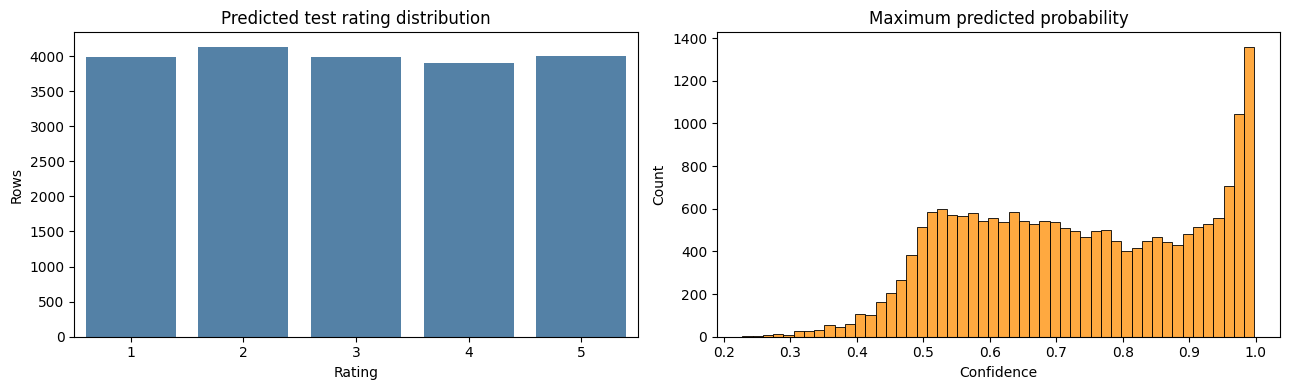

In [8]:
prediction_distribution = (
    pd.Series(test_predictions, name='predicted')
    .value_counts()
    .sort_index()
    .reindex([1, 2, 3, 4, 5], fill_value=0)
    .to_frame('count')
)
prediction_distribution['percentage'] = (
    prediction_distribution['count'] / test_rows * 100
).round(2)
display(prediction_distribution)

confidence_summary = pd.Series(test_confidence).describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)
display(confidence_summary.to_frame('confidence'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(
    x=prediction_distribution.index,
    y=prediction_distribution['count'],
    ax=axes[0], color='steelblue'
)
axes[0].set(title='Predicted test rating distribution', xlabel='Rating', ylabel='Rows')
sns.histplot(test_confidence, bins=50, ax=axes[1], color='darkorange')
axes[1].set(title='Maximum predicted probability', xlabel='Confidence')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'test_prediction_diagnostics.png', dpi=160)
plt.show()

## Save detailed predictions and official submission

The detailed CSV is for analysis only. The official submission must contain exactly one column named `predicted` and no index.

In [9]:
details = pd.DataFrame({
    'row_id': test_df['_row_id'].to_numpy(),
    'predicted': test_predictions,
    'confidence': test_confidence,
    'entropy': test_entropy,
})
for class_index in range(NUM_CLASSES):
    details[f'prob_rating_{class_index + 1}'] = test_probabilities[:, class_index]

submission = pd.DataFrame({'predicted': test_predictions})

assert details['row_id'].eq(np.arange(test_rows)).all()
assert submission.shape == (test_rows, 1)
assert submission.columns.tolist() == ['predicted']
assert submission['predicted'].between(1, 5).all()
assert not submission['predicted'].isna().any()

submission_path = OUTPUT_DIR / 'q2_submission.csv'
details_path = OUTPUT_DIR / 'test_predictions_detailed.csv'
distribution_path = OUTPUT_DIR / 'test_prediction_distribution.csv'
submission.to_csv(submission_path, index=False)
details.to_csv(details_path, index=False)
prediction_distribution.to_csv(distribution_path, index_label='predicted')

print('Saved:', submission_path)
print('Saved:', details_path)
print('Saved:', distribution_path)
display(submission.head())

Saved: /kaggle/working/roberta_test_inference/q2_submission.csv
Saved: /kaggle/working/roberta_test_inference/test_predictions_detailed.csv
Saved: /kaggle/working/roberta_test_inference/test_prediction_distribution.csv


,predicted
0,1
1,1
2,1
3,1
4,1


## Inspect the least-confident predictions

This is qualitative error-risk analysis only; without labels we cannot know whether these predictions are wrong.

In [10]:
analysis_columns = [
    column for column in ['reviewText', 'summary', 'verified_str', 'vote_bucket', 'model_input']
    if column in test_df.columns
]
low_confidence_rows = (
    details.nsmallest(50, 'confidence')
    .merge(test_df[['_row_id'] + analysis_columns], left_on='row_id', right_on='_row_id')
    .drop(columns='_row_id')
)
low_confidence_rows.to_csv(OUTPUT_DIR / 'lowest_confidence_examples.csv', index=False)
display(low_confidence_rows.head(10))

,row_id,predicted,confidence,entropy,prob_rating_1,prob_rating_2,prob_rating_3,prob_rating_4,prob_rating_5,reviewText,summary,verified_str,vote_bucket,model_input
0,1870,3,0.227834,1.590249,0.210198,0.127398,0.227834,0.227528,0.207041,Important update:Uupdate... If you register th...,"Dont buy from Amazon, Reolink will not take a ...",yes,5_to_9,Verified: yes | Helpful votes: 5_to_9 | Summar...
1,12065,5,0.242446,1.578527,0.220777,0.222074,0.204997,0.109707,0.242446,"The MacBook 12"" has one USB C port and of cour...",Real Apple is the way to go,yes,0_to_4,Verified: yes | Helpful votes: 0_to_4 | Summar...
2,13859,1,0.244433,1.593571,0.244433,0.147013,0.193144,0.233097,0.182312,"ERCRYSTO Card Reader and 3 Ports Usb Hub, High...","ERCRYSTO Card Reader and 3 Ports Usb Hub, High...",yes,0_to_4,Verified: yes | Helpful votes: 0_to_4 | Summar...
3,13723,1,0.248499,1.580846,0.248499,0.219219,0.220131,0.196927,0.115225,Update- seller contacted me and sent a replace...,"Not a good battery, sending this one back",yes,missing,Verified: yes | Helpful votes: missing | Summa...
4,12248,1,0.259373,1.584510,0.259373,0.142333,0.185601,0.168736,0.243956,These work great with the Optiplex 745 and the...,These work great with the Optiplex 745 and the...,yes,10_to_49,Verified: yes | Helpful votes: 10_to_49 | Summ...
5,14624,3,0.259396,1.578195,0.194887,0.231248,0.259396,0.198431,0.116038,"After a year, the drives suddenly freak out. I...",all ports fail after plugging in flash drive (...,yes,missing,Verified: yes | Helpful votes: missing | Summa...
6,12722,4,0.267326,1.585169,0.234079,0.146393,0.168000,0.267326,0.184202,There are two parts to my review. The first is...,The most amazing all round headphones I have h...,yes,5_to_9,Verified: yes | Helpful votes: 5_to_9 | Summar...
7,6956,3,0.270320,1.563503,0.104396,0.170104,0.270320,0.243262,0.211918,"I have a well functioning Raspberry Pi, but co...","I have a well functioning Raspberry Pi, but co...",yes,missing,Verified: yes | Helpful votes: missing | Summa...
8,8604,3,0.270950,1.568254,0.180282,0.139405,0.270950,0.265709,0.143655,"Dear friend, Greeting! You purchased a GPS Nav...",what if you don't have a pay pal acount ?,yes,missing,Verified: yes | Helpful votes: missing | Summa...
9,17459,3,0.273168,1.556437,0.165897,0.264118,0.273168,0.103253,0.193563,I have several of these Western Digital 1TB ex...,Western Digital personal storage devices are t...,yes,missing,Verified: yes | Helpful votes: missing | Summa...


## Output contract

The file submitted for scoring is `/kaggle/working/roberta_test_inference/q2_submission.csv`. Do not submit `test_predictions_detailed.csv`; it intentionally contains additional diagnostic columns.